In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color
from skimage.segmentation import chan_vese
from skimage import img_as_float

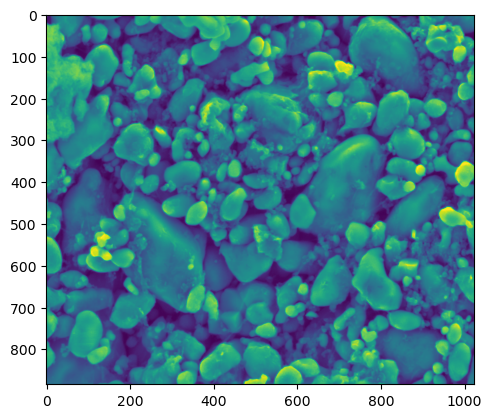

In [5]:
# -----------------------------
# 1. Load image
# -----------------------------
image = io.imread("sem_data/LFP_backscatter_fresh_001.tif")

# Convert to grayscale if needed
if image.ndim == 3:
    image = color.rgb2gray(image)

# Convert to float (recommended)
image = img_as_float(image)
plt.imshow(image)

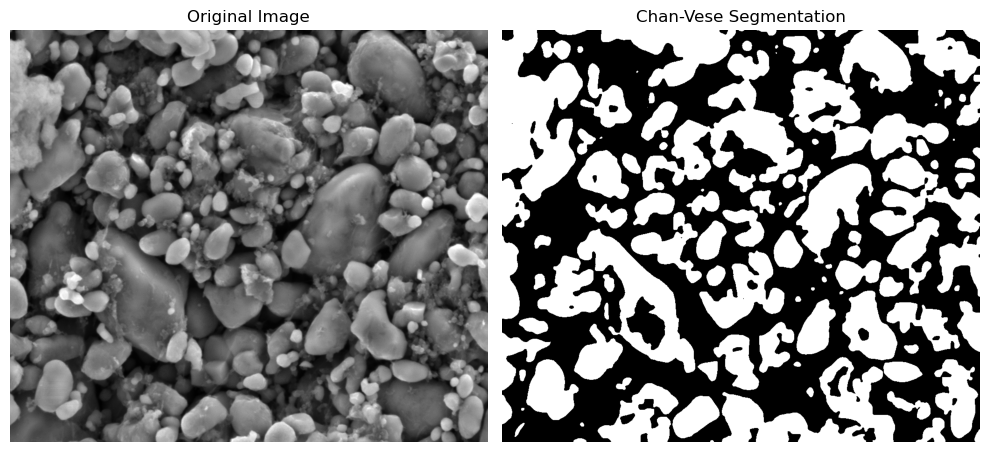

In [16]:
# 2. Run Chan-Vese segmentation
# -----------------------------
segmentation = chan_vese(
    image,
    mu=0.25,                # smoothness of contour
    lambda1=1,              # weight for inside region
    lambda2=1,              # weight for outside region
    tol=1e-3,               # convergence tolerance
    max_num_iter=500,       # maximum iterations
    dt=0.5,                 # step size
    init_level_set="checkerboard",  # initial contour
    extended_output=False
)


# -----------------------------
# 3. Visualize results
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(~segmentation, cmap="gray")
axes[1].set_title("Chan-Vese Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()